In [1]:
# import necessary packages
import cmapPy.pandasGEXpress.GCToo as GCToo
import pandas as pd
from cmapPy.pandasGEXpress.parse import parse
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

## Select only the 978 landmark genes and all the samples that had a high transcriptional response to drug compounds

#### *1. Select the 978 landmark gene ids to extract from .gctx file*

In [2]:
# read gene info from gene_info metadata
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/GSE70138_Broad_LINCS_gene_info_2017-03-06.txt"
gene_info = pd.read_csv(file_path, sep="\t", dtype=str)
gene_info.head()

,pr_gene_id,pr_gene_symbol,pr_gene_title,pr_is_lm,pr_is_bing
0,780,DDR1,discoidin domain receptor tyrosine kinase 1,1,1
1,7849,PAX8,paired box 8,1,1
2,2978,GUCA1A,guanylate cyclase activator 1A,0,0
3,2049,EPHB3,EPH receptor B3,0,1
4,2101,ESRRA,estrogen related receptor alpha,0,1


In [3]:
# select the ids of only the landmark genes
lm_gene_id = gene_info["pr_gene_id"][gene_info["pr_is_lm"] == "1"]

# check that I have the 978 landmark genes
print(len(lm_gene_id)) 

978


#### *2. Filter out only the trt_cp data using GSE70138_Broad_LINCS_sig_info.txt and save into trt_cps_sig_info.txt with the command line:*
``` bash
grep trt_cp GSE70138_Broad_LINCS_sig_info.txt | cut -f-3,5-8 > trt_cps.txt
head -1 GSE70138_Broad_LINCS_sig_info.txt | cut -f-3,5-8 > column_names_sig_info.txt
cat column_names_sig_info.txt trt_cps.txt > trt_cps_sig_info.txt
rm column_names_sig_info.txt trt_cps.txt
```

#### *3. Extract trt_cps and save as TAS_trt_cps.txt using the following command:*
```bash
grep trt_cp GSE70138_Broad_LINCS_sig_metrics_2017-03-06.txt | cut -f2,5-6,8 > trt_cps.txt
head -1 GSE70138_Broad_LINCS_sig_metrics_2017-03-06.txt | cut -f2,5-6,8 > column_names_sig_metrics.txt
cat column_names_sig_metrics.txt trt_cps.txt > TAS_trt_cps.txt
rm column_names_sig_metrics.txt trt_cps.txt
```

## Select the gene signatures ids of compounds of interest

#### *1. Select all gene signature info with MCF7*

In [4]:
# read the gene signature info
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/trt_cps_sig_info.txt"
sig_info = pd.read_csv(file_path, sep="\t", dtype=str)
sig_info.set_index("sig_id", inplace=True)

In [5]:
# select only the gene signature ids with MCF7
MCF7_sig_info = sig_info[sig_info['cell_id'] == 'MCF7']
MCF7_sig_info.head()

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id
sig_id,,,,,,
LJP005_MCF7_24H:A07,BRD-K76908866,CP-724714,MCF7,10.0 um,24 h,LJP005_MCF7_24H_X1_B17:A07|LJP005_MCF7_24H_X2_...
LJP005_MCF7_24H:A08,BRD-K76908866,CP-724714,MCF7,3.33 um,24 h,LJP005_MCF7_24H_X1_B17:A08|LJP005_MCF7_24H_X2_...
LJP005_MCF7_24H:A09,BRD-K76908866,CP-724714,MCF7,1.11 um,24 h,LJP005_MCF7_24H_X1_B17:A09|LJP005_MCF7_24H_X2_...
LJP005_MCF7_24H:A10,BRD-K76908866,CP-724714,MCF7,0.37 um,24 h,LJP005_MCF7_24H_X1_B17:A10|LJP005_MCF7_24H_X2_...
LJP005_MCF7_24H:A11,BRD-K76908866,CP-724714,MCF7,0.12 um,24 h,LJP005_MCF7_24H_X1_B17:A11|LJP005_MCF7_24H_X2_...


In [6]:
# total number of gene signatures
len(MCF7_sig_info)

12737

#### *2. From these gene signatures, select only those with very high transcriptional responses (TAS > 0.6)*

##### a. Add the TAS scores to the sig_id info

In [7]:
# read the TAS scores of the gene signatures
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/TAS_trt_cps.txt"
tas_trt_cps = pd.read_csv(file_path, sep="\t", dtype=str)
tas_trt_cps.set_index('sig_id', inplace=True)
tas_trt_cps.head()

,pert_id,pert_iname,tas
sig_id,,,
REP.A001_A375_24H:A07,BRD-K25114078,aminoguanidine,0.111322
REP.A001_A375_24H:A08,BRD-K25114078,aminoguanidine,0.104451
REP.A001_A375_24H:A09,BRD-K25114078,aminoguanidine,0.113235
REP.A001_A375_24H:A10,BRD-K25114078,aminoguanidine,0.0747183
REP.A001_A375_24H:A11,BRD-K25114078,aminoguanidine,0.107109


In [8]:
# add the TAS scores to the sig_info for MCF7
MCF7_trt_cps = MCF7_sig_info.merge(tas_trt_cps, on=['sig_id', 'pert_id','pert_iname'], how='inner')
MCF7_trt_cps.head()

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id,tas
sig_id,,,,,,,
LJP005_MCF7_24H:A07,BRD-K76908866,CP-724714,MCF7,10.0 um,24 h,LJP005_MCF7_24H_X1_B17:A07|LJP005_MCF7_24H_X2_...,0.207429
LJP005_MCF7_24H:A08,BRD-K76908866,CP-724714,MCF7,3.33 um,24 h,LJP005_MCF7_24H_X1_B17:A08|LJP005_MCF7_24H_X2_...,0.303676
LJP005_MCF7_24H:A09,BRD-K76908866,CP-724714,MCF7,1.11 um,24 h,LJP005_MCF7_24H_X1_B17:A09|LJP005_MCF7_24H_X2_...,0.231824
LJP005_MCF7_24H:A10,BRD-K76908866,CP-724714,MCF7,0.37 um,24 h,LJP005_MCF7_24H_X1_B17:A10|LJP005_MCF7_24H_X2_...,0.109656
LJP005_MCF7_24H:A11,BRD-K76908866,CP-724714,MCF7,0.12 um,24 h,LJP005_MCF7_24H_X1_B17:A11|LJP005_MCF7_24H_X2_...,0.244196


In [9]:
# total of number of compounds with tas scores
len(MCF7_trt_cps)

10581

##### b. Sort TAS scores in descending order and select only those where TAS > 0.6

In [10]:
# sort the TAS scores in descending order
top_trt_cps = MCF7_trt_cps.sort_values(by='tas', ascending=False)
top_trt_cps['tas'] = top_trt_cps['tas'].astype(float)

# select only the ones with very high response (TAS > 0.6)
high_tas_trt_cps = top_trt_cps[top_trt_cps['tas'] > 0.6]

# check that the table ends at 0.6
high_tas_trt_cps.tail(10)

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id,tas
sig_id,,,,,,,
REP.A024_MCF7_24H:E09,BRD-A74914197,pralatrexate,MCF7,1.11 um,24 h,REP.A024_MCF7_24H_X1_B23:E09|REP.A024_MCF7_24H...,0.604770
REP.A004_MCF7_24H:I23,BRD-K23363278,CYT-997,MCF7,0.12 um,24 h,REP.A004_MCF7_24H_X1_B27:I23|REP.A004_MCF7_24H...,0.604288
REP.A002_MCF7_24H:K19,BRD-K17705806,JTC-801,MCF7,10.0 um,24 h,REP.A002_MCF7_24H_X1_B27:K19|REP.A002_MCF7_24H...,0.604279
REP.A003_MCF7_24H:A19,BRD-K23499943,alvespimycin,MCF7,10.0 um,24 h,REP.A003_MCF7_24H_X1_B27:A19|REP.A003_MCF7_24H...,0.604228
REP.A023_MCF7_24H:H09,BRD-K69776681,volasertib,MCF7,1.11 um,24 h,REP.A023_MCF7_24H_X1_B23:H09|REP.A023_MCF7_24H...,0.603907
REP.A027_MCF7_24H:D22,BRD-K93779381,ingenol-mebutate,MCF7,0.37 um,24 h,REP.A027_MCF7_24H_X1_B25:D22|REP.A027_MCF7_24H...,0.603704
REP.A008_MCF7_24H:C02,BRD-K36740062,GSK-1070916,MCF7,3.33 um,24 h,REP.A008_MCF7_24H_X1_B24:C02|REP.A008_MCF7_24H...,0.603602
REP.A002_MCF7_24H:K07,BRD-K60230970,MG-132,MCF7,20.0 um,24 h,REP.A002_MCF7_24H_X1_B27:K07|REP.A002_MCF7_24H...,0.601651
LJP008_MCF7_24H:I07,BRD-K16485616,mocetinostat,MCF7,10.0 um,24 h,LJP008_MCF7_24H_X1_B20:I07|LJP008_MCF7_24H_X2_...,0.600766


## Check the gene signatures of bortezimib of MCF7 cell line

In [11]:
# from the MCF7 gene sig info with high TAS scores (all gene info w/ bortezimib), 
# select only those with bortezimib
bortezimib_gene_info = high_tas_trt_cps[high_tas_trt_cps['pert_iname'] == 'bortezomib']

# check that you have all the samples
bortezimib_gene_info.head()

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id,tas
sig_id,,,,,,,
REP.A020_MCF7_24H:G13,BRD-K50691590,bortezomib,MCF7,20.0 um,24 h,REP.A020_MCF7_24H_X1_B23:G13|REP.A020_MCF7_24H...,0.826145
REP.A008_MCF7_24H:C22,BRD-K50691590,bortezomib,MCF7,20.0 um,24 h,REP.A008_MCF7_24H_X1_B24:C22|REP.A008_MCF7_24H...,0.815444
REP.A020_MCF7_24H:C22,BRD-K50691590,bortezomib,MCF7,20.0 um,24 h,REP.A020_MCF7_24H_X1_B23:C22|REP.A020_MCF7_24H...,0.811573
REP.A015_MCF7_24H:C23,BRD-K50691590,bortezomib,MCF7,20.0 um,24 h,REP.A015_MCF7_24H_X1_B23:C23|REP.A015_MCF7_24H...,0.811346
REP.A020_MCF7_24H:C23,BRD-K50691590,bortezomib,MCF7,20.0 um,24 h,REP.A020_MCF7_24H_X1_B23:C23|REP.A020_MCF7_24H...,0.809700


## Map the drugs to the diseases

The diseases related to each drug was taken from the Broad Institute:
https://repo-hub.broadinstitute.org/repurposing#download-data

In [12]:
# import the disease information for each drug
file_path = '/home/katie_huang_student_uml_edu/LINCS_dataset/repurposing_drugs_20200324.txt'
disease_info = pd.read_csv(file_path, sep="\t", dtype=str, skiprows=9)

# set the index as the name of the compound
disease_info.set_index('pert_iname', inplace=True)
disease_info.head()

,clinical_phase,moa,target,disease_area,indication
pert_iname,,,,,
(R)-(-)-apomorphine,Launched,dopamine receptor agonist,ADRA2A|ADRA2B|ADRA2C|CALY|DRD1|DRD2|DRD3|DRD4|...,neurology/psychiatry,Parkinson's Disease
(R)-(-)-rolipram,Phase 1,phosphodiesterase inhibitor,PDE4A|PDE4B|PDE4C|PDE4D|PDE5A,NaN,NaN
(R)-baclofen,Phase 3,benzodiazepine receptor agonist,GABBR1|GABBR2,NaN,NaN
(S)-(+)-rolipram,Phase 1,phosphodiesterase inhibitor,PDE4B|PDE4D,NaN,NaN
"[sar9,met(o2)11]-substance-p",Preclinical,tachykinin antagonist,TACR1,NaN,NaN


In [13]:
# remove pert_inames where there is no indication (NaN)
disease_info = disease_info[disease_info['indication'].notna()]
disease_info.head()

,clinical_phase,moa,target,disease_area,indication
pert_iname,,,,,
(R)-(-)-apomorphine,Launched,dopamine receptor agonist,ADRA2A|ADRA2B|ADRA2C|CALY|DRD1|DRD2|DRD3|DRD4|...,neurology/psychiatry,Parkinson's Disease
abacavir,Launched,nucleoside reverse transcriptase inhibitor,NaN,infectious disease,human immunodeficiency virus (HIV-1)
abamectin,Launched,benzodiazepine receptor agonist,GABBR1|GABBR2,infectious disease,gastrointestinal parasites
abemaciclib,Launched,CDK inhibitor,CDK4|CDK6,oncology,breast cancer
abiraterone,Launched,androgen biosynthesis inhibitor,CYP11B1|CYP17A1,oncology,prostate cancer


In [15]:
# obtain the pert_info data
file_path = '/home/katie_huang_student_uml_edu/LINCS_dataset/GSE70138_Broad_LINCS_pert_info.txt'
pert_info = pd.read_csv(file_path, sep="\t", dtype=str)

# set the index of the dataframe as the pert_iname
pert_info.set_index('pert_iname', inplace=True)
pert_info.head()

,pert_id,canonical_smiles,inchi_key,pert_type
pert_iname,,,,
10-DEBC,BRD-K70792160,CCN(CC)CCCCN1c2ccccc2Oc2ccc(Cl)cc12,GYBXAGDWMCJZJK-UHFFFAOYSA-N,trt_cp
phorbol-myristate-acetate,BRD-K68552125,CCCCCCCCCCCCCC(=O)O[C@@H]1[C@@H](C)[C@]2(O)[C@...,PHEDXBVPIONUQT-RGYGYFBISA-N,trt_cp
"16,16-dimethylprostaglandin-e2",BRD-K92301463,CCCCC(C)(C)[C@H](O)\C=C\[C@H]1[C@H](O)CC(=O)[C...,QAOBBBBDJSWHMU-WMBBNPMCSA-N,trt_cp
17-hydroxyprogesterone-caproate,BRD-A29731977,CCCCCC(=O)O[C@@]1(CCC2C3CCC4=CC(=O)CC[C@]4(C)C...,DOMWKUIIPQCAJU-JKPPDDDBSA-N,trt_cp
2-iminobiotin,BRD-K07954936,OC(=O)CCCC[C@@H]1SC[C@@H]2NC(=N)N[C@H]12,WWVANQJRLPIHNS-ZKWXMUAHSA-N,trt_cp


In [16]:
# select only the drugs associated with a disease
drug_to_disease = pert_info.merge(disease_info, how='inner', on='pert_iname')
drug_to_disease.head()

,pert_id,canonical_smiles,inchi_key,pert_type,clinical_phase,moa,target,disease_area,indication
pert_iname,,,,,,,,,
17-hydroxyprogesterone-caproate,BRD-A29731977,CCCCCC(=O)O[C@@]1(CCC2C3CCC4=CC(=O)CC[C@]4(C)C...,DOMWKUIIPQCAJU-JKPPDDDBSA-N,trt_cp,Launched,progesterone receptor agonist,AR|ESR1|ESR2|NR1H4|NR1I2|NR3C1|PGR,obstetrics/gynecology,spontaneous preterm birth
5-aminolevulinic-acid,BRD-K57631554,NCC(=O)CCC(O)=O,ZGXJTSGNIOSYLO-UHFFFAOYSA-N,trt_cp,Launched,oxidizing agent,ALAD,oncology|dermatology,glioma|actinic keratosis (AK)
abacavir,BRD-A95032015,Nc1nc(NC2CC2)c2ncn(C3C[C@H](CO)C=C3)c2n1,MCGSCOLBFJQGHM-HNHGDDPOSA-N,trt_cp,Launched,nucleoside reverse transcriptase inhibitor,NaN,infectious disease,human immunodeficiency virus (HIV-1)
abiraterone-acetate,BRD-K16133773,CC(=O)O[C@H]1CC[C@]2(C)[C@@H]3CC[C@@]4(C)[C@@H...,UVIQSJCZCSLXRZ-HCWFNAMGSA-N,trt_cp,Launched,androgen biosynthesis inhibitor,CYP17A1,oncology,prostate cancer
acarbose,BRD-K01621533,C[C@@H]1O[C@H](O[C@@H]2[C@H](CO)O[C@H](O[C@@H]...,XUFXOAAUWZOOIT-PCKYEMPFSA-N,trt_cp,Launched,glucosidase inhibitor,AMY2A|MGAM,endocrinology,diabetes mellitus


In [17]:
# calculate the total number of drugs associated with a disease
len(drug_to_disease)

884

In [18]:
# sort the drugs by their disease area and disease indication
drug_to_disease = drug_to_disease.sort_values(by=['disease_area', 'indication'])
drug_to_disease.head(10)

,pert_id,canonical_smiles,inchi_key,pert_type,clinical_phase,moa,target,disease_area,indication
pert_iname,,,,,,,,,
acrivastine,BRD-K50163129,Cc1ccc(cc1)C(=C/CN1CCCC1)\c1cccc(\C=C\C(O)=O)n1,PWACSDKDOHSSQD-IUTFFREVSA-N,trt_cp,Launched,histamine receptor antagonist,HRH1,allergy,allergic rhinitis
beclomethasone-dipropionate,BRD-A11319535,CCC(=O)OCC(=O)C1(OC(=O)CC)C(C)CC2C3CCC4=CC(=O)...,KUVIULQEHSCUHY-UHFFFAOYSA-N,trt_cp,Launched,glucocorticoid receptor agonist,GPR97|NR3C1,allergy,allergic rhinitis
ciclesonide,BRD-K35245662,CC(C)C(=O)OCC(=O)[C@@]12O[C@@H](O[C@@H]1C[C@H]...,LUKZNWIVRBCLON-GXOBDPJESA-N,trt_cp,Launched,glucocorticoid receptor agonist,NR3C1|SERPINA6,allergy,allergic rhinitis
clemizole,BRD-K04704168,Clc1ccc(Cn2c(CN3CCCC3)nc3ccccc23)cc1,CJXAEXPPLWQRFR-UHFFFAOYSA-N,trt_cp,Launched,HCV inhibitor,NaN,allergy,allergic rhinitis
diphenylpyraline,BRD-K22936972,CN1CCC(CC1)OC(c1ccccc1)c1ccccc1,OWQUZNMMYNAXSL-UHFFFAOYSA-N,trt_cp,Launched,dopamine reuptake inhibitor,HRH1|SLC6A3,allergy,allergic rhinitis
histamine,BRD-K01674964,NCCc1c[nH]cn1,NTYJJOPFIAHURM-UHFFFAOYSA-N,trt_cp,Launched,histamine receptor agonist,HRH1|HRH2|HRH3|HRH4,allergy,allergic rhinitis
homochlorcyclizine,BRD-A22769835,CN1CCCN(CC1)C(c1ccccc1)c1ccc(Cl)cc1,WEUCDJCFJHYFRL-UHFFFAOYSA-N,trt_cp,Launched,antihistamine,HRH1,allergy,allergic rhinitis
oxatomide,BRD-K02079473,O=c1[nH]c2ccccc2n1CCCN1CCN(CC1)C(c1ccccc1)c1cc...,BAINIUMDFURPJM-UHFFFAOYSA-N,trt_cp,Launched,histamine receptor antagonist,HRH1,allergy,allergic rhinitis
chlorphenamine,BRD-A04553218,CN(C)CCC(c1ccc(Cl)cc1)c1ccccn1,SOYKEARSMXGVTM-UHFFFAOYSA-N,trt_cp,Launched,histamine receptor antagonist,NaN,allergy,allergic rhinitis|urticaria


## Select drugs to compare based on these disease indications

#### *1. Show only the compounds that have high TAS scores with a drug indication*

In [19]:
# select all the samples with high TAS scores treated with MCF7 that have a disease associated with it
test_samples = high_tas_trt_cps[high_tas_trt_cps['pert_iname'].isin(drug_to_disease.index)]

# unique compound ids with associated diseases
unique_cp_ids = test_samples['pert_id'].unique()

In [20]:
unique_cp_ids

array(['BRD-K50691590', 'BRD-K14619660', 'BRD-K56844688', 'BRD-A45889380',
       'BRD-K13646352', 'BRD-K76674262', 'BRD-K61397605', 'BRD-K72951360',
       'BRD-A68009927', 'BRD-K15179879', 'BRD-A33084557', 'BRD-A94756469',
       'BRD-K92093830', 'BRD-K73088654', 'BRD-K35960502', 'BRD-K88510285',
       'BRD-K81418486', 'BRD-K92213669', 'BRD-K47869605', 'BRD-K57041787',
       'BRD-K77987382', 'BRD-K21680192', 'BRD-K17743125', 'BRD-K78431006',
       'BRD-K43586850', 'BRD-K68346641', 'BRD-K15409150', 'BRD-K75649340',
       'BRD-K55026842', 'BRD-K79131256', 'BRD-A74914197', 'BRD-A79768653',
       'BRD-K74717603', 'BRD-K52020312', 'BRD-A67097164', 'BRD-K06335600',
       'BRD-K93779381', 'BRD-K49350383'], dtype=object)

In [21]:
# number of unique compounds with associated diseases
len(unique_cp_ids)

38

#### *2. Categorize the pert_ids by their indication*

In [22]:
# list the indication of these compounds
drug2indications = drug_to_disease[['pert_id', 'indication']][drug_to_disease['pert_id'].isin(unique_cp_ids)]
drug2indications

,pert_id,indication
pert_iname,,
digoxin,BRD-A94756469,congestive heart failure|atrial fibrillation (AF)
lacidipine,BRD-K43586850,hypertension
ingenol-mebutate,BRD-K93779381,actinic keratosis (AK)
metronidazole,BRD-K52020312,rosacea
altrenogest,BRD-K14619660,estrus
lomitapide,BRD-K92213669,hypercholesterolemia
amsacrine,BRD-K68346641,acute lymphoblastic leukemia (ALL)
midostaurin,BRD-K13646352,acute myeloid leukemia (AML)
thioguanine,BRD-K49350383,acute myeloid leukemia (AML)


In [23]:
# for each drug that has multiple indications
# separate it so that there are multiple rows for that drug, each with one indication

# create a list to store the new rows
new_rows = []

# iterate through each row of the DataFrame
for index, row in drug2indications.iterrows():
    # separate the indications for that drug
    indications = row['indication'].split('|')
    # for each indication
    for indication in indications:
        # make a copy of that data for that drug
        new_row = row.copy()
        # and replace all indications with just that indication
        new_row['indication'] = indication
        # store this in new rows
        new_rows.append(new_row)
        
# replace the data using this new data
drug2indications= pd.DataFrame(new_rows)

drug2indications.head(20)

,pert_id,indication
digoxin,BRD-A94756469,congestive heart failure
digoxin,BRD-A94756469,atrial fibrillation (AF)
lacidipine,BRD-K43586850,hypertension
ingenol-mebutate,BRD-K93779381,actinic keratosis (AK)
metronidazole,BRD-K52020312,rosacea
altrenogest,BRD-K14619660,estrus
lomitapide,BRD-K92213669,hypercholesterolemia
amsacrine,BRD-K68346641,acute lymphoblastic leukemia (ALL)
midostaurin,BRD-K13646352,acute myeloid leukemia (AML)
thioguanine,BRD-K49350383,acute myeloid leukemia (AML)


In [24]:
# find the unique indications
unique_indications = drug2indications['indication'].unique()
unique_indications

array(['congestive heart failure', 'atrial fibrillation (AF)',
       'hypertension', 'actinic keratosis (AK)', 'rosacea', 'estrus',
       'hypercholesterolemia', 'acute lymphoblastic leukemia (ALL)',
       'acute myeloid leukemia (AML)', 'chronic myeloid leukemia (CML)',
       'cutaneous T-cell lymphoma (CTCL)', 'multiple myeloma',
       'mantle cell lymphoma (MCL)', 'peripheral T-cell lymphoma (PTCL)',
       'myelodysplastic diseases (MDS)', 'anemia',
       'chronic myelomonocytic leukemia (CMMoL)', "Wilm's tumor",
       'breast cancer', 'ovarian cancer', "Hodgkin's lymphoma",
       'bladder cancer', 'cystic hydatid disease',
       'parenchymal neurocysticercosis', 'genital warts', 'giardiasis',
       'human immunodeficiency virus (HIV-1)', 'pinworm', 'whipworm',
       'hookworm', 'ascariasis', 'tapeworm', 'yeast infection',
       'schizophrenia', 'spasms', 'stroke', 'systemic embolism',
       'pulmonary embolism (PE)', 'deep vein thrombosis (DVT)',
       'multiple scle

In [25]:
# create separate datasets for each indication

# create an empty dictionary to contain only drugs for each unique indication
df_by_indications = {}
# for each unique indication, 
for indication in unique_indications:
    # add the dataframe consisting only the drugs for that indication
    df_by_indications[indication] = drug2indications[drug2indications['indication'] == indication]


## remove datasets that only have one compound
# create an empty list that will contain all the indications with only one drug (can't be compared with)
indications_to_remove = []
# iterate through the dictionary,
for indication, df in df_by_indications.items():
    # if it only has one compound
    if len(df) == 1:
        # add it to the list of keys to remove
        indications_to_remove.append(indication)

# remove the datasets for the indications that only have one drug
for indication in indications_to_remove:
    del df_by_indications[indication]

In [26]:
## checking that each dataset consists only of one indication
df_by_indications

{'acute lymphoblastic leukemia (ALL)':                     pert_id                          indication
 amsacrine     BRD-K68346641  acute lymphoblastic leukemia (ALL)
 daunorubicin  BRD-A68009927  acute lymphoblastic leukemia (ALL)
 tioguanine    BRD-K75649340  acute lymphoblastic leukemia (ALL)
 doxorubicin   BRD-K92093830  acute lymphoblastic leukemia (ALL),
 'acute myeloid leukemia (AML)':                     pert_id                    indication
 midostaurin   BRD-K13646352  acute myeloid leukemia (AML)
 thioguanine   BRD-K49350383  acute myeloid leukemia (AML)
 daunorubicin  BRD-A68009927  acute myeloid leukemia (AML)
 tioguanine    BRD-K75649340  acute myeloid leukemia (AML)
 doxorubicin   BRD-K92093830  acute myeloid leukemia (AML)
 mitoxantrone  BRD-K21680192  acute myeloid leukemia (AML),
 'bladder cancer':                    pert_id      indication
 doxorubicin  BRD-K92093830  bladder cancer
 valrubicin   BRD-K72951360  bladder cancer,
 'breast cancer':                    pe

## Compare drugs of one indication (test)

#### *1. Select the drugs targeting one indication (chronic myeloid leukemia (CML))*

In [27]:
# defining function to select relevant data at one dose
def select_dose(sig_info, dose):
    return sig_info[sig_info['pert_idose'] == dose]

In [28]:
# get the list of pert_ids of one dataset
cps2compare = df_by_indications['chronic myeloid leukemia (CML)']['pert_id']

In [29]:
# select the sig_info for these compounds
test_cps_sig_info = high_tas_trt_cps[high_tas_trt_cps['pert_id'].isin(cps2compare)]
test_cps_sig_info

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id,tas
sig_id,,,,,,,
REP.A025_MCF7_24H:L10,BRD-K76674262,homoharringtonine,MCF7,0.37 um,24 h,REP.A025_MCF7_24H_X1_B23:L10|REP.A025_MCF7_24H...,0.799271
REP.A025_MCF7_24H:L11,BRD-K76674262,homoharringtonine,MCF7,0.12 um,24 h,REP.A025_MCF7_24H_X1_B23:L11|REP.A025_MCF7_24H...,0.798702
REP.A025_MCF7_24H:L08,BRD-K76674262,homoharringtonine,MCF7,3.33 um,24 h,REP.A025_MCF7_24H_X1_B23:L08|REP.A025_MCF7_24H...,0.773170
REP.A025_MCF7_24H:L09,BRD-K76674262,homoharringtonine,MCF7,1.11 um,24 h,REP.A025_MCF7_24H_X1_B23:L09|REP.A025_MCF7_24H...,0.768873
REP.A025_MCF7_24H:L07,BRD-K76674262,homoharringtonine,MCF7,10.0 um,24 h,REP.A025_MCF7_24H_X1_B23:L07|REP.A025_MCF7_24H...,0.741634
REP.A025_MCF7_24H:L12,BRD-K76674262,homoharringtonine,MCF7,0.04 um,24 h,REP.A025_MCF7_24H_X1_B23:L12|REP.A025_MCF7_24H...,0.714157
REP.A025_MCF7_24H:J19,BRD-K75649340,tioguanine,MCF7,10.0 um,24 h,REP.A025_MCF7_24H_X1_B23:J19|REP.A025_MCF7_24H...,0.658646


There's only one sample of tioguanine that was treated at 10.0 um so only select 10.0 um dose to compare.

In [30]:
test_cps_sig_info = select_dose(test_cps_sig_info, '10.0 um')
test_cps_sig_info

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id,tas
sig_id,,,,,,,
REP.A025_MCF7_24H:L07,BRD-K76674262,homoharringtonine,MCF7,10.0 um,24 h,REP.A025_MCF7_24H_X1_B23:L07|REP.A025_MCF7_24H...,0.741634
REP.A025_MCF7_24H:J19,BRD-K75649340,tioguanine,MCF7,10.0 um,24 h,REP.A025_MCF7_24H_X1_B23:J19|REP.A025_MCF7_24H...,0.658646


In [31]:
# store the sig ids of these compounds
test_cps_sig_ids = test_cps_sig_info.index

#### *2. Select the gene signatures for selected compounds*

In [32]:
# read the LINCS Level 5 dataset
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/LINCS_dataset.gctx"

# select only the landmark genes of drug compounds of interest
dose_gene_sigs = parse(file_path, rid=lm_gene_id, cid=test_cps_sig_ids)

# create a new GCTOO object that contains the sig_info as the columns and gene_sigs as rows
sig_info = GCToo.GCToo(data_df=dose_gene_sigs.data_df.copy(), 
                       row_metadata_df=dose_gene_sigs.row_metadata_df.copy(), 
                       col_metadata_df=test_cps_sig_info, 
                       make_multiindex=True)
sig_info.multi_index_df[:5]

pert_id,BRD-K75649340,BRD-K76674262
pert_iname,tioguanine,homoharringtonine
cell_id,MCF7,MCF7
pert_idose,10.0 um,10.0 um
pert_itime,24 h,24 h
distil_id,REP.A025_MCF7_24H_X1_B23:J19|REP.A025_MCF7_24H_X2_B23:J19|REP.A025_MCF7_24H_X3_B23:J19,REP.A025_MCF7_24H_X1_B23:L07|REP.A025_MCF7_24H_X2_B23:L07
tas,0.658646,0.741634
cid,REP.A025_MCF7_24H:J19,REP.A025_MCF7_24H:L07
rid,,
0,-0.240879,0.64120
1,-0.630775,-0.94095


#### *3. Perform Spearman Correlation Between the Drugs*

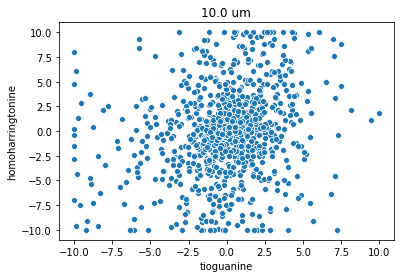

SpearmanrResult(correlation=0.2243185883295826, pvalue=1.2770476315128295e-12)


In [33]:
sns.scatterplot(
    x = sig_info.data_df.iloc[:, 0],
    y = sig_info.data_df.iloc[:, 1]
    )

# label x-axis of the scatterplot with the compound name
plt.xlabel(sig_info.col_metadata_df.iloc[0].pert_iname)
# label y-axis of the scatterplot with the compound name
plt.ylabel(sig_info.col_metadata_df.iloc[1].pert_iname)
# label title with dose being compared at
plt.title(sig_info.col_metadata_df.iloc[0].pert_idose)
plt.show()

# perform a spearman correlation
print(stats.spearmanr(sig_info.data_df.iloc[:, 0], sig_info.data_df.iloc [:,1]))

In [34]:
# obtain all the different dosages
pert_idoses = test_cps_sig_info["pert_idose"].unique()

# initialize a list to store all the gene signatures and sig info for each dose in pert_idose
sig_infos = []

In [35]:
# read the LINCS Level 5 dataset
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/LINCS_dataset.gctx"

# separate gene signatures by each dose in pert_idose
for dose in pert_idoses:
    # select gene signatures of one dose
    dose_sig_info = select_dose(test_cps_sig_info, dose)
    
    # select the gene signature ids
    dose_sig_ids = dose_sig_info.index
    
    # select only the landmark genes of drug compounds of interest
    dose_gene_sigs = parse(file_path, rid=lm_gene_id, cid=dose_sig_ids)
    
    # create a new GCTOO object that contains the sig_info as the columns and gene_sigs as rows
    sig_info = GCToo.GCToo(data_df=dose_gene_sigs.data_df.copy(), 
                                              row_metadata_df=dose_gene_sigs.row_metadata_df.copy(), 
                                              col_metadata_df=dose_sig_info, 
                                             make_multiindex=True)
    
    # store sig_info
    sig_infos.append(sig_info)

In [36]:
# snapshot of what each dataset looks like for each dose
sig_infos[0].multi_index_df[:5]

pert_id,BRD-K75649340,BRD-K76674262
pert_iname,tioguanine,homoharringtonine
cell_id,MCF7,MCF7
pert_idose,10.0 um,10.0 um
pert_itime,24 h,24 h
distil_id,REP.A025_MCF7_24H_X1_B23:J19|REP.A025_MCF7_24H_X2_B23:J19|REP.A025_MCF7_24H_X3_B23:J19,REP.A025_MCF7_24H_X1_B23:L07|REP.A025_MCF7_24H_X2_B23:L07
tas,0.658646,0.741634
cid,REP.A025_MCF7_24H:J19,REP.A025_MCF7_24H:L07
rid,,
0,-0.240879,0.64120
1,-0.630775,-0.94095


## Automate comparison on drugs with same indication

#### *1. Automate the dose selection process*

In [37]:
# defining function to select only the samples with common dosages for one indication
def select_dose(sig_info, sig_info_by_indication):
    # create an empty list to contain unique dosages for each compound
    all_doses = []
    # obtain the unique compounds in dataset
    unique_cps = sig_info['pert_id'].unique()
     
    # for each unique compound
    for cp in unique_cps:
        # find all the unique doses for that compound
        cp_doses = set(sig_info['pert_idose'][sig_info['pert_id'] == cp])
        # add it to the running list of unique doses
        all_doses.append(cp_doses)
    
    # find all the common doses across all unique compounds
    common_doses = all_doses[0].intersection(*all_doses[1:])
    
    # if there is a common dose across all unique compounds
    if len(common_doses) > 0:
        # obtain all data with those the unique doses
        common_dose_sigs = sig_info[sig_info['pert_idose'].isin(common_doses)]
        
        # create a dictionary for each unique dose
        sigs_by_dose = {}
        
        # group the dataset by dose
        grouped_sigs = common_dose_sigs.groupby('pert_idose')
        
        # for each dose in grouped data,
        for dose, data in grouped_sigs:
            # add the data for each unique dose
            sigs_by_dose[dose] = data
        
        # and add them to the dictionary containing its indication
        sig_info_by_indication[indication] = sigs_by_dose

In [38]:
# filter the datasets with common dosages for all indications

# create a new dictionary to store filtered datasets
sig_info_by_indication = {}

# for each indication,
for indication in df_by_indications:
    # obtain all the drugs for that indication
    df = df_by_indications[indication]
    # get the list of pert_id of the drugs
    cps2compare = df['pert_id']
    # select the sig_info for these compounds
    sig_info = high_tas_trt_cps[high_tas_trt_cps['pert_id'].isin(cps2compare)]
    
    # select only the doses in common
    select_dose(sig_info, sig_info_by_indication)

# show the list of unique indications with data from 2+ drugs targeting MCF7 cell line w/ TAS scores > 0.6
sig_info_by_indication.keys()

['bladder cancer',
 'chronic myeloid leukemia (CML)',
 'acute lymphoblastic leukemia (ALL)',
 'acute myeloid leukemia (AML)',
 'breast cancer']

In [39]:
# example showing that the dictionary of one indication is separated by common dose
sig_info_by_indication['bladder cancer'].keys()

['10.0 um', '3.33 um']

#### *2. Automate reading in the gene signatures of these samples*

In [54]:
def read_sigs_for_indication(file_path, lm_gene_id, sig_info_by_dose):
    # create an empty dictionary containing the gene signatures at each dose
    sigs_by_dose = {}
    # for each dataset pertaining to that dose
    for dose in sig_info_by_dose:
        # obtain the sig ids at that dose
        sig_ids = sig_info_by_dose[dose].index
        # obtain the metadata for all samples at that dose
        metadata = sig_info_by_dose[dose]
        
        # select only the landmark genes of drug compounds of interest
        dose_gene_sigs = parse(file_path, rid=lm_gene_id, cid=sig_ids)

        # create a new GCTOO object that contains the sig_info as the columns and gene_sigs as rows
        sigs_info = GCToo.GCToo(data_df=dose_gene_sigs.data_df.copy(), 
                               row_metadata_df=dose_gene_sigs.row_metadata_df.copy(), 
                               col_metadata_df=metadata, 
                               make_multiindex=True)
        
        # add it as the dataset
        sigs_by_dose[dose] = sigs_info
        
    return sigs_by_dose

In [56]:
# read the LINCS Level 5 dataset
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/LINCS_dataset.gctx"

# create an empty dictionary to store the gene signatures of the samples at each dose for each indication
sigs_by_indication = {}

# for each indication, obtain the gene signatures of all samples for each dose
for indication in sig_info_by_indication:
    # create separate datasets containing the gene signatures of the samples at each dose for one indication
    sig_info = read_sigs_for_indication(file_path, lm_gene_id, sig_info_by_indication[indication])
    
    # add it to the dictionary with all indications
    sigs_by_indication[indication] = sig_info

sigs_by_indication.keys()

['bladder cancer',
 'chronic myeloid leukemia (CML)',
 'acute lymphoblastic leukemia (ALL)',
 'acute myeloid leukemia (AML)',
 'breast cancer']

#### *3. Perform Spearman correlations*

In [68]:
# function to create a scatter plot for each drug dosage comparing 2 drug compounds
def spearman_correlation(sigs_by_dose, col1_idx, col2_idx):
    for dose in sigs_by_dose:
        # get the data for that dose
        dose_sig_info = sigs_by_dose[dose]
        plt.figure()
        
        # make a scatterplot 
        sns.scatterplot(
            x = dose_sig_info.data_df.iloc[:, col1_idx],
            y = dose_sig_info.data_df.iloc[:, col2_idx]
        )
        # label x-axis of the scatterplot with the compound name
        plt.xlabel(dose_sig_info.col_metadata_df.iloc[col1_idx].pert_iname)
        # label y-axis of the scatterplot with the compound name
        plt.ylabel(dose_sig_info.col_metadata_df.iloc[col2_idx].pert_iname)
        # label title with dose being compared at
        plt.title(dose_sig_info.col_metadata_df.iloc[col1_idx].pert_idose)
        plt.show()

        # perform a spearman correlation
        print(stats.spearmanr(dose_sig_info.data_df.iloc[:, col1_idx], dose_sig_info.data_df.iloc [:,col2_idx]))

#### Bladder cancer

In [89]:
# show the doses available
data = sigs_by_indication['bladder cancer']
data.keys()

['10.0 um', '3.33 um']

In [90]:
# show the sample gene signatures for 10.0 um dose
data['10.0 um'].multi_index_df[:5]

pert_id,BRD-K72951360,BRD-K92093830
pert_iname,valrubicin,doxorubicin
cell_id,MCF7,MCF7
pert_idose,10.0 um,10.0 um
pert_itime,24 h,24 h
distil_id,REP.A023_MCF7_24H_X1_B23:O13|REP.A023_MCF7_24H_X2_B23:O13|REP.A023_MCF7_24H_X3_B23:O13,REP.A026_MCF7_24H_X2_B25:L19|REP.A026_MCF7_24H_X3_B25:L19
tas,0.794730,0.616557
cid,REP.A023_MCF7_24H:O13,REP.A026_MCF7_24H:L19
rid,,
0,3.560683,-0.62770
1,1.229628,3.18515


In [91]:
# show the sample gene signatures for 10.0 um dose
data['3.33 um'].multi_index_df[:5]

pert_id,BRD-K72951360,BRD-K92093830
pert_iname,valrubicin,doxorubicin
cell_id,MCF7,MCF7
pert_idose,3.33 um,3.33 um
pert_itime,24 h,24 h
distil_id,REP.A023_MCF7_24H_X1_B23:O14|REP.A023_MCF7_24H_X2_B23:O14|REP.A023_MCF7_24H_X3_B23:O14,REP.A026_MCF7_24H_X1_B25:L20|REP.A026_MCF7_24H_X2_B25:L20|REP.A026_MCF7_24H_X3_B25:L20
tas,0.615495,0.732233
cid,REP.A023_MCF7_24H:O14,REP.A026_MCF7_24H:L20
rid,,
0,5.653194,-0.546943
1,-0.449780,0.574483


Both have 2 samples so no need to adjust code for spearman_correlation function.

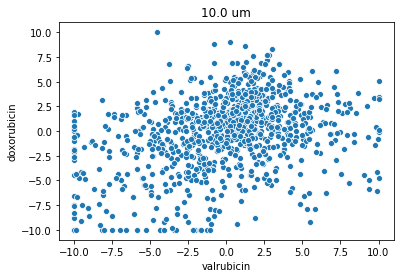

SpearmanrResult(correlation=0.32624176938977545, pvalue=1.0959330957628237e-25)


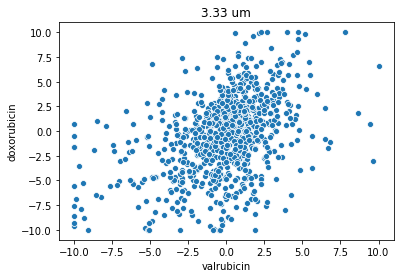

SpearmanrResult(correlation=0.4087870818209087, pvalue=1.0989738951143582e-40)


In [92]:
# comparing bladder drug samples
spearman_correlation(data, 0, 1)

#### Chronic myeloid leukemia (CML)

In [123]:
# show doses available to analyze
data = sigs_by_indication['chronic myeloid leukemia (CML)']
data.keys()

['10.0 um']

In [124]:
# show sample dataset with drug info for chronic myeloid leukemia (CML)
data['10.0 um'].multi_index_df[:5]

pert_id,BRD-K75649340,BRD-K76674262
pert_iname,tioguanine,homoharringtonine
cell_id,MCF7,MCF7
pert_idose,10.0 um,10.0 um
pert_itime,24 h,24 h
distil_id,REP.A025_MCF7_24H_X1_B23:J19|REP.A025_MCF7_24H_X2_B23:J19|REP.A025_MCF7_24H_X3_B23:J19,REP.A025_MCF7_24H_X1_B23:L07|REP.A025_MCF7_24H_X2_B23:L07
tas,0.658646,0.741634
cid,REP.A025_MCF7_24H:J19,REP.A025_MCF7_24H:L07
rid,,
0,-0.240879,0.64120
1,-0.630775,-0.94095


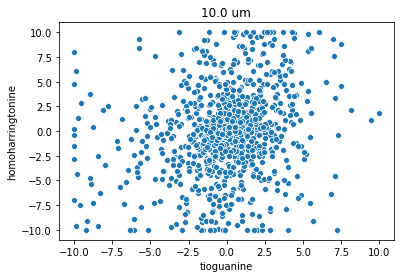

SpearmanrResult(correlation=0.2243185883295826, pvalue=1.2770476315128295e-12)


In [125]:
# comparing chronic myeloid leukemia (CML) drug samples
spearman_correlation(data, 0, 1)

#### Acute lymphoblastic leukemia (ALL)

In [126]:
# show all doses available to analyze
data = sigs_by_indication['acute lymphoblastic leukemia (ALL)']
data.keys()

['10.0 um']

In [107]:
# show sample gene signatures at dose
data['10.0 um'].multi_index_df[:5]

pert_id,BRD-A68009927,BRD-K68346641,BRD-K75649340,BRD-K92093830
pert_iname,daunorubicin,amsacrine,tioguanine,doxorubicin
cell_id,MCF7,MCF7,MCF7,MCF7
pert_idose,10.0 um,10.0 um,10.0 um,10.0 um
pert_itime,24 h,24 h,24 h,24 h
distil_id,REP.A008_MCF7_24H_X2_B24:A07|REP.A008_MCF7_24H_X3_B24:A07,REP.A023_MCF7_24H_X1_B23:D07|REP.A023_MCF7_24H_X2_B23:D07|REP.A023_MCF7_24H_X3_B23:D07,REP.A025_MCF7_24H_X1_B23:J19|REP.A025_MCF7_24H_X2_B23:J19|REP.A025_MCF7_24H_X3_B23:J19,REP.A026_MCF7_24H_X2_B25:L19|REP.A026_MCF7_24H_X3_B25:L19
tas,0.742199,0.660436,0.658646,0.616557
cid,REP.A008_MCF7_24H:A07,REP.A023_MCF7_24H:D07,REP.A025_MCF7_24H:J19,REP.A026_MCF7_24H:L19
rid,,,,
0,-1.22085,2.053771,-0.240879,-0.62770
1,5.82705,0.509816,-0.630775,3.18515


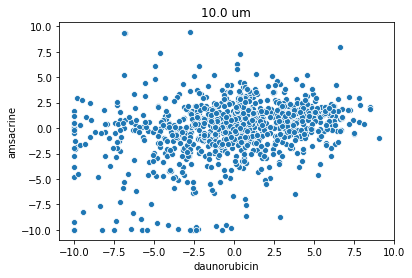

SpearmanrResult(correlation=0.2872119136878963, pvalue=4.988969017616217e-20)


In [108]:
# compare daunorubicin to amsacrine
spearman_correlation(data, 0, 1)

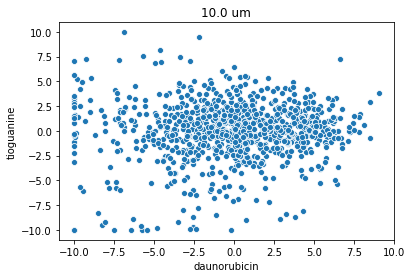

SpearmanrResult(correlation=0.01215211329359786, pvalue=0.7042713615995853)


In [110]:
# compare daunorubicin to tioguanine
spearman_correlation(data, 0, 2)

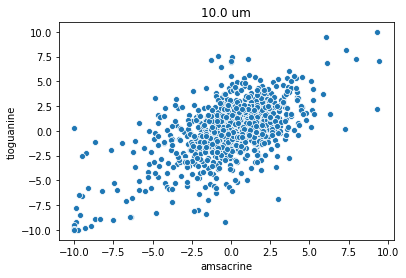

SpearmanrResult(correlation=0.48734979137530743, pvalue=1.7707840712058917e-59)


In [111]:
# compare amsacrine to tioguanine
spearman_correlation(data, 1, 2)

#### Acute myeloid leukemia (AML)

In [127]:
# show the doses available
data = sigs_by_indication['acute myeloid leukemia (AML)']
data.keys()

['10.0 um']

In [128]:
# show the sample gene signatures for 10.0 um dose
data['10.0 um'].multi_index_df[:5]

pert_id,BRD-K21680192,BRD-A68009927,BRD-K13646352,BRD-K49350383,BRD-K75649340,BRD-K92093830,BRD-K21680192
pert_iname,mitoxantrone,daunorubicin,midostaurin,thioguanine,tioguanine,doxorubicin,mitoxantrone
cell_id,MCF7,MCF7,MCF7,MCF7,MCF7,MCF7,MCF7
pert_idose,10.0 um,10.0 um,10.0 um,10.0 um,10.0 um,10.0 um,10.0 um
pert_itime,24 h,24 h,24 h,24 h,24 h,24 h,24 h
distil_id,REP.A006_MCF7_24H_X1_B22:I13|REP.A006_MCF7_24H_X2_B24:I13|REP.A006_MCF7_24H_X3_B22:I13,REP.A008_MCF7_24H_X2_B24:A07|REP.A008_MCF7_24H_X3_B24:A07,REP.A010_MCF7_24H_X1_B24:I01|REP.A010_MCF7_24H_X2_B24:I01|REP.A010_MCF7_24H_X3_B24:I01,REP.A019_MCF7_24H_X1_B23:K19|REP.A019_MCF7_24H_X2_B24:K19|REP.A019_MCF7_24H_X3_B23:K19,REP.A025_MCF7_24H_X1_B23:J19|REP.A025_MCF7_24H_X2_B23:J19|REP.A025_MCF7_24H_X3_B23:J19,REP.A026_MCF7_24H_X2_B25:L19|REP.A026_MCF7_24H_X3_B25:L19,LJP006_MCF7_24H_X1_B17:C19|LJP006_MCF7_24H_X2_B17:C19|LJP006_MCF7_24H_X3_B17:C19|LJP006_MCF7_24H_X4_B19:C19
tas,0.645893,0.742199,0.794343,0.617237,0.658646,0.616557,0.605699
cid,REP.A006_MCF7_24H:I13,REP.A008_MCF7_24H:A07,REP.A010_MCF7_24H:I01,REP.A019_MCF7_24H:K19,REP.A025_MCF7_24H:J19,REP.A026_MCF7_24H:L19,LJP006_MCF7_24H:C19
rid,,,,,,,
0,1.562286,-1.22085,1.669526,-1.283763,-0.240879,-0.62770,-0.577483
1,1.850216,5.82705,3.920308,0.038814,-0.630775,3.18515,0.940561


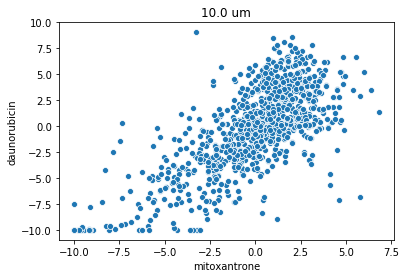

SpearmanrResult(correlation=0.6637110558512699, pvalue=3.208654206808701e-125)


In [131]:
# compare mitoxantrone to daunorubicin
spearman_correlation(data, 0, 1)

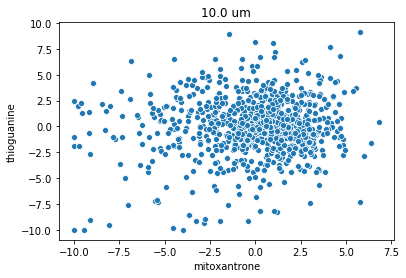

SpearmanrResult(correlation=0.0239696592427875, pvalue=0.45400676753449587)


In [132]:
# compare mitoxantrone to thioguanine
spearman_correlation(data, 0, 3)

NOTE: There are multiple samples for the same drug

#### Breast cancer

In [133]:
# show the doses available
data = sigs_by_indication['breast cancer']
data.keys()

['1.11 um', '0.37 um', '10.0 um', '3.33 um']

In [135]:
# show the sample gene signatures for 1.11 um dose
data['1.11 um'].multi_index_df[:5]

pert_id,BRD-K56844688,BRD-K92093830
pert_iname,epirubicin,doxorubicin
cell_id,MCF7,MCF7
pert_idose,1.11 um,1.11 um
pert_itime,24 h,24 h
distil_id,REP.A015_MCF7_24H_X1_B23:E09|REP.A015_MCF7_24H_X2_B23:E09|REP.A015_MCF7_24H_X3_B23:E09,REP.A026_MCF7_24H_X1_B25:L21|REP.A026_MCF7_24H_X2_B25:L21|REP.A026_MCF7_24H_X3_B25:L21
tas,0.743891,0.617229
cid,REP.A015_MCF7_24H:E09,REP.A026_MCF7_24H:L21
rid,,
0,5.427455,0.228489
1,0.868441,3.089116


In [136]:
# show the sample gene signatures for 0.37 um dose
data['0.37 um'].multi_index_df[:5]

pert_id,BRD-K56844688,BRD-K92093830
pert_iname,epirubicin,doxorubicin
cell_id,MCF7,MCF7
pert_idose,0.37 um,0.37 um
pert_itime,24 h,24 h
distil_id,REP.A015_MCF7_24H_X1_B23:E10|REP.A015_MCF7_24H_X2_B23:E10|REP.A015_MCF7_24H_X3_B23:E10,REP.A026_MCF7_24H_X1_B25:L22|REP.A026_MCF7_24H_X2_B25:L22|REP.A026_MCF7_24H_X3_B25:L22
tas,0.733259,0.673786
cid,REP.A015_MCF7_24H:E10,REP.A026_MCF7_24H:L22
rid,,
0,5.796515,1.410865
1,0.214063,0.031179


In [137]:
# show the sample gene signatures for 10.0 um dose
data['10.0 um'].multi_index_df[:5]

pert_id,BRD-K56844688,BRD-K92093830
pert_iname,epirubicin,doxorubicin
cell_id,MCF7,MCF7
pert_idose,10.0 um,10.0 um
pert_itime,24 h,24 h
distil_id,REP.A015_MCF7_24H_X1_B23:E07|REP.A015_MCF7_24H_X2_B23:E07|REP.A015_MCF7_24H_X3_B23:E07,REP.A026_MCF7_24H_X2_B25:L19|REP.A026_MCF7_24H_X3_B25:L19
tas,0.795630,0.616557
cid,REP.A015_MCF7_24H:E07,REP.A026_MCF7_24H:L19
rid,,
0,2.282938,-0.62770
1,8.008051,3.18515


In [138]:
# show the sample gene signatures for 3.33 um dose
data['3.33 um'].multi_index_df[:5]

pert_id,BRD-K56844688,BRD-K92093830
pert_iname,epirubicin,doxorubicin
cell_id,MCF7,MCF7
pert_idose,3.33 um,3.33 um
pert_itime,24 h,24 h
distil_id,REP.A015_MCF7_24H_X1_B23:E08|REP.A015_MCF7_24H_X2_B23:E08|REP.A015_MCF7_24H_X3_B23:E08,REP.A026_MCF7_24H_X1_B25:L20|REP.A026_MCF7_24H_X2_B25:L20|REP.A026_MCF7_24H_X3_B25:L20
tas,0.807126,0.732233
cid,REP.A015_MCF7_24H:E08,REP.A026_MCF7_24H:L20
rid,,
0,0.539207,-0.546943
1,1.504347,0.574483


All have 2 samples so can run spearman correlation as it is

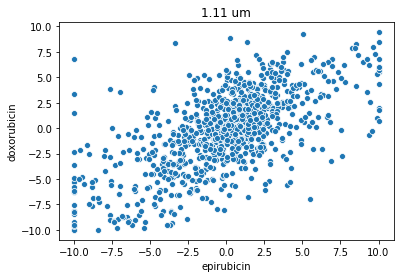

SpearmanrResult(correlation=0.6059201398151047, pvalue=4.5953721766727886e-99)


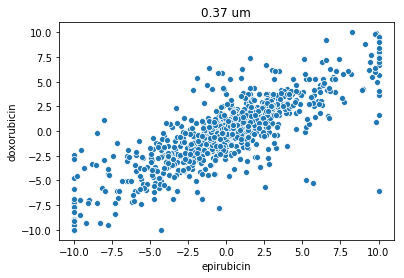

SpearmanrResult(correlation=0.7924747650227457, pvalue=8.385916459067516e-212)


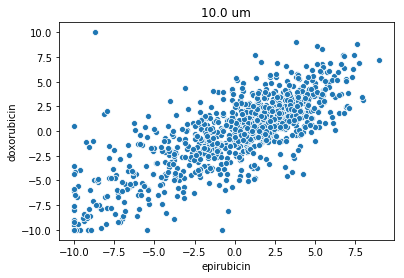

SpearmanrResult(correlation=0.762204132867889, pvalue=1.5411523802677803e-186)


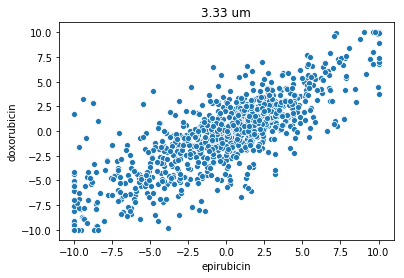

SpearmanrResult(correlation=0.770544790562287, pvalue=4.13775356265066e-193)


In [139]:
spearman_correlation(data, 0, 1)